# Objetivo do trabalho
Uso da ResNet18 para detecção de cancer de intestino

### Download do LC25000 através do kaggle

In [1]:
from google.colab import files
!pip install -q kaggle

In [2]:
def upload_kaggle_dataset_in_colab():
    files.upload()
    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

def unzip_kaggle_dataset_in_colab():
    !kaggle datasets download -d andrewmvd/lung-and-colon-cancer-histopathological-images
    !unzip -q lung-and-colon-cancer-histopathological-images.zip

def unzip_support_functions_in_colab():
    !kaggle datasets download -d gabrielcruzvazsantos/colon-detection-support-functions
    !unzip -q colon-detection-support-functions.zip


def get_kaggle_dataset_in_colab():
    upload_kaggle_dataset_in_colab()
    unzip_kaggle_dataset_in_colab()
    unzip_support_functions_in_colab()

In [3]:
get_kaggle_dataset_in_colab()

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/lung-and-colon-cancer-histopathological-images
License(s): CC-BY-SA-4.0
 99% 1.74G/1.76G [00:09<00:00, 255MB/s]
100% 1.76G/1.76G [00:09<00:00, 190MB/s]
Dataset URL: https://www.kaggle.com/datasets/gabrielcruzvazsantos/colon-detection-support-functions
License(s): unknown
  0% 0.00/4.00k [00:00<?, ?B/s]
100% 4.00k/4.00k [00:00<00:00, 14.3MB/s]


## Uso de código externo
Esse notebook foi preparado para utilizar código modular python externo que, para seu devido funcionamento, precisa ser feito o upload via

In [4]:
from get_formatted_datasets import get_formatted_datasets
from get_dataloaders import get_dataloaders
from train_and_test_model import train_model, test_model


In [5]:
import torch
import torchvision
from abc import ABC, abstractmethod
import matplotlib.pyplot as plt
from tabulate import tabulate
import seaborn as sns


### Datasets e dataLoader

In [6]:
df_train, df_validation, df_test = get_formatted_datasets()

100%|██████████| 10002/10002 [00:00<00:00, 21905.15it/s]


CSV salvo com sucesso em: nb_lc25000.csv


In [7]:
dataloader_train, dataloader_validation, dataloader_test = get_dataloaders(df_train, df_validation, df_test)

### Modelo e treinamento
- Resnet18
- Canais de entrada - imagem RGB: 3
- Saída - Problema de classificação binária: 2
- Taxa de aprendizado: 1e-4

In [8]:
in_channels = 3
output_features = 2
learning_rate = 1e-4

In [ ]:
model = torchvision.models.resnet18(num_classes=output_features)

In [ ]:
model = model.to("cuda")

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
train_losses, val_losses, best_model = train_model(model, dataloader_train, dataloader_validation, optimizer)

Epoch 1: Train Loss = 0.2607 | Val Loss = 0.2765
Epoch 2: Train Loss = 0.0969 | Val Loss = 0.1120
Epoch 3: Train Loss = 0.0722 | Val Loss = 0.1036
Epoch 4: Train Loss = 0.0584 | Val Loss = 0.1510
Epoch 5: Train Loss = 0.0450 | Val Loss = 0.1711
Epoch 6: Train Loss = 0.0402 | Val Loss = 0.4673
Epoch 7: Train Loss = 0.0297 | Val Loss = 0.1043
Epoch 8: Train Loss = 0.0250 | Val Loss = 0.1152
Epoch 9: Train Loss = 0.0273 | Val Loss = 0.0564
Epoch 10: Train Loss = 0.0224 | Val Loss = 0.2101


#### imprimindo resultados do treinamento e validação

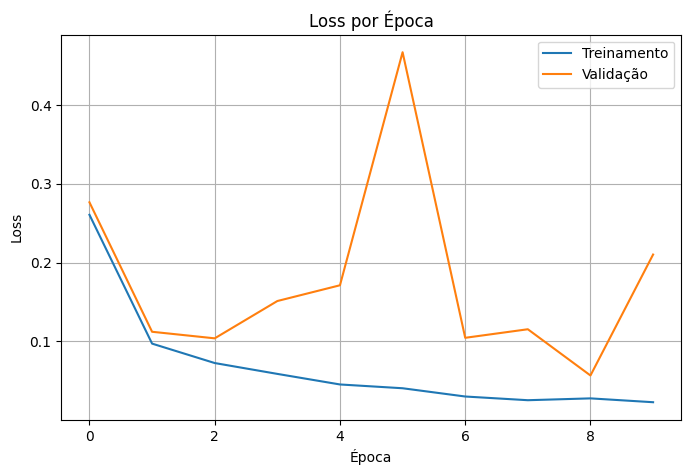

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Treinamento")
plt.plot(val_losses, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

### Testando modelo

In [ ]:
acc, precision, recall, f1, cm = test_model(best_model, "cuda", dataloader_test)

Acurácia: 0.9855
Precisão (weighted): 0.9857
Recall (weighted): 0.9855
F1-score (weighted): 0.9855
Matriz de Confusão:
[[996   4]
 [ 25 975]]


In [ ]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc:.4f}"],
["Precisão (weighted)", f"{precision:.4f}"],
["Recall (weighted)", f"{recall:.4f}"],
["F1-score (weighted)", f"{f1:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.9855 │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.9857 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.9855 │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.9855 │
╘═════════════════════╧═════════╛


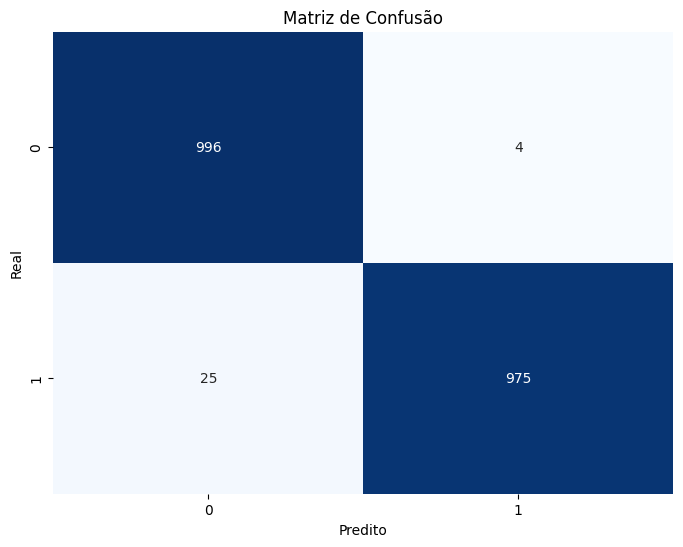

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

### Treinamento com Weight decay
Pode-se observar que a loss de validação não está convergindo. Com isso, o resultado de teste só esta sendo bom devido ao uso do melhor modelo
Logo, a tentativa será de adicionar o decaimento de pesos para evitar explosão de valores e também aumentar o número de épocas

In [9]:
wd_model = torchvision.models.resnet18(num_classes=output_features)
wd_model = wd_model.to("cuda")

In [10]:
wd_optimizer = torch.optim.Adam(wd_model.parameters(), lr=learning_rate, weight_decay=1e-5)

In [11]:
train_losses_wd, val_losses_wd, best_model_wd = train_model(wd_model, dataloader_train, dataloader_validation, wd_optimizer, epochs=15)

Epoch 1: Train Loss = 0.2560 | Val Loss = 0.1692
Epoch 2: Train Loss = 0.1001 | Val Loss = 0.3234
Epoch 3: Train Loss = 0.0706 | Val Loss = 0.1898
Epoch 4: Train Loss = 0.0545 | Val Loss = 0.3737
Epoch 5: Train Loss = 0.0430 | Val Loss = 0.3169
Epoch 6: Train Loss = 0.0400 | Val Loss = 0.3416
Epoch 7: Train Loss = 0.0308 | Val Loss = 0.0867
Epoch 8: Train Loss = 0.0284 | Val Loss = 0.1179
Epoch 9: Train Loss = 0.0305 | Val Loss = 0.0821
Epoch 10: Train Loss = 0.0248 | Val Loss = 0.4309
Epoch 11: Train Loss = 0.0257 | Val Loss = 0.5658
Epoch 12: Train Loss = 0.0253 | Val Loss = 0.5729
Epoch 13: Train Loss = 0.0207 | Val Loss = 0.4313
Epoch 14: Train Loss = 0.0222 | Val Loss = 0.6076
Epoch 15: Train Loss = 0.0233 | Val Loss = 0.0460


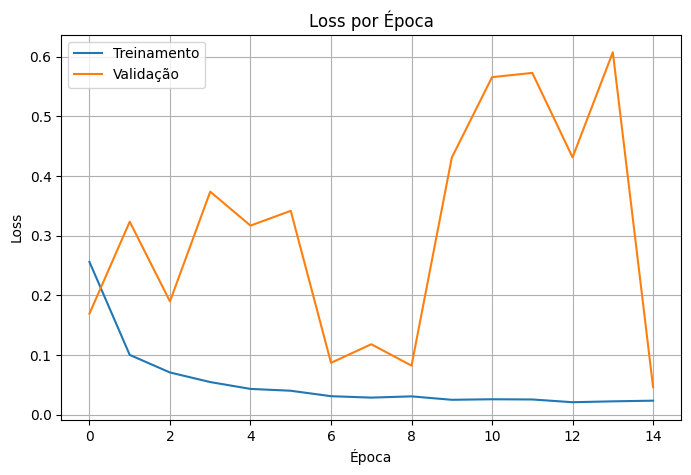

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses_wd, label="Treinamento")
plt.plot(val_losses_wd, label="Validação")
plt.title("Loss por Época")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
acc_wd, precisiond_wd, recall_wd, f1_wd, cm_wd = test_model(best_model_wd, "cuda", dataloader_test)

Acurácia: 0.9795
Precisão (weighted): 0.9803
Recall (weighted): 0.9795
F1-score (weighted): 0.9795
Matriz de Confusão:
[[1000    0]
 [  41  959]]


In [14]:
headers = ["Métrica", "Valor"]
table = [
["Acurácia", f"{acc_wd:.4f}"],
["Precisão (weighted)", f"{precisiond_wd:.4f}"],
["Recall (weighted)", f"{recall_wd:.4f}"],
["F1-score (weighted)", f"{f1_wd:.4f}"],
]
print(tabulate(table, headers=headers, tablefmt="fancy_grid"))

╒═════════════════════╤═════════╕
│ Métrica             │   Valor │
╞═════════════════════╪═════════╡
│ Acurácia            │  0.9795 │
├─────────────────────┼─────────┤
│ Precisão (weighted) │  0.9803 │
├─────────────────────┼─────────┤
│ Recall (weighted)   │  0.9795 │
├─────────────────────┼─────────┤
│ F1-score (weighted) │  0.9795 │
╘═════════════════════╧═════════╛


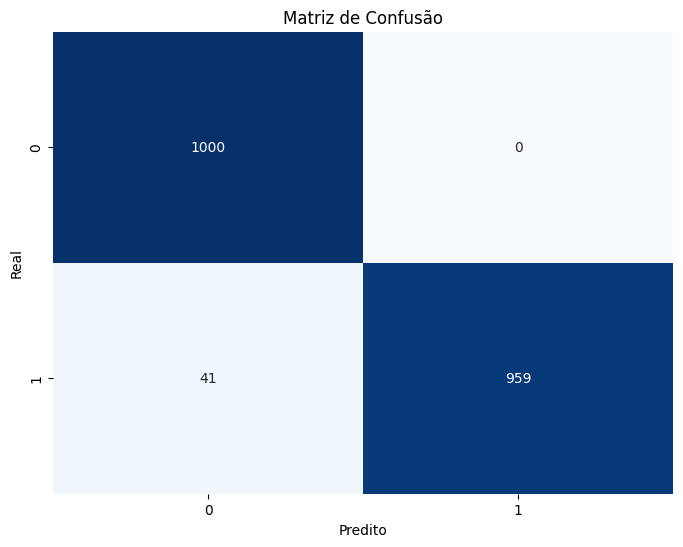

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm_wd, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Matriz de Confusão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()